### Bipin Pun(ACE080BCT023)

### Lab4: Regression-using-PyTorch

### Objectives:

1.To understand the concept of regression and its applications in machine learning.

2.To learn how to create and manipulate tensors using PyTorch.

3.To implement a Linear Regression model using PyTorch.

4.To understand the role of loss functions and optimization algorithms in model training.

5.To train, evaluate, and make predictions using a regression model.

### PyTorch for Regression:

PyTorch is an open-source deep learning framework that provides tensor operations, automatic differentiation (Autograd), neural network modules, and optimization tools for building machine learning models efficiently.

### Tensors in PyTorch:

Tensors are multidimensional arrays that store numerical data and serve as the basic data structure in PyTorch. They are similar to NumPy arrays but can utilize GPU acceleration for faster computation.

### 4. Linear Regression Model:

Linear Regression models the relationship between input and output variables using a straight-line equation.
i.e. y = wx + b

where:

y = predicted output
x = input feature
w = weight (slope)
b = bias (intercept)

The objective is to find the optimal values of weight and bias that minimize prediction error.

In [1]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu132

Looking in indexes: https://download.pytorch.org/whl/cu132
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.12.0+cu132'

In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


Machine learning is a game of two parts:

Turn your data, whatever it is, into numbers (a representation).
Pick or build a model to learn the representation as best as possible
First let's import the dataset, a synthetic linear dataset generated by y = 0.7·x + 0.3. We'll train a model to see if it can recover the slope (0.7) and intercept (0.3).

### 1. Data Preparation

In [3]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [4]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [5]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [6]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});
 

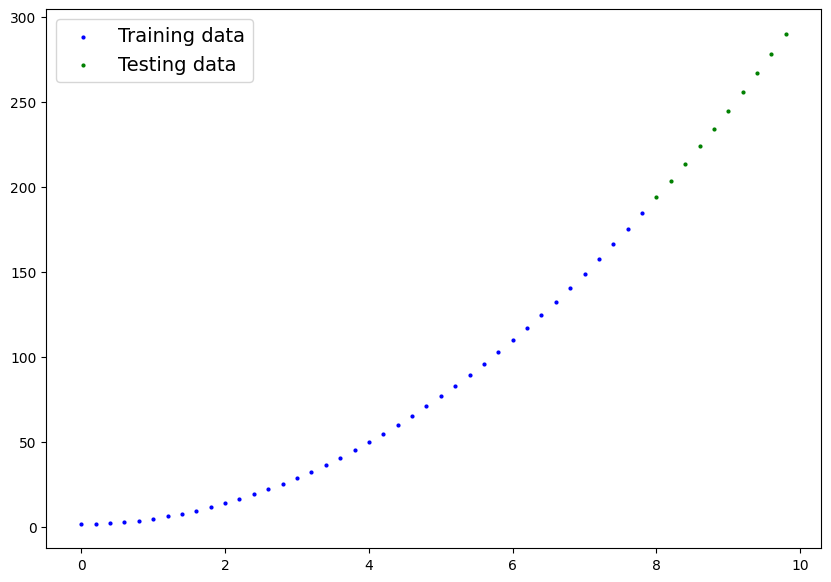

In [7]:
# Note: If you've reset your runtime, this function won't work,
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

Algorithm Selection
Now we've got some data, let's build a model to use the blue dots to predict the green dots.

We're going to jump right in.

We'll write the code first and then explain everything.

Let's replicate a standard linear regression model using pure PyTorch.

In [8]:
import torch.nn as nn

# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

### Pytorch Model building Essentials:

torch.nn : collection of neural-network components (layers, activations, losses) used to build models.

torch.nn.Parameter : a tensor wrapper for model parameters; when requires_grad=True it’s tracked for gradient-based updates.

torch.nn.Module : base class for models/layers; create your network by subclassing it and using its utilities.

torch.optim : optimization algorithms (SGD, Adam, etc.) that update Parameters using gradients.

def forward() : the method you implement in an nn.Module that defines the layer/model’s forward computation on input data.

In [9]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


In [11]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917]])

In [12]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917],
        [3.1590],
        [3.2264],
        [3.2937],
        [3.3610],
        [3.4284]])


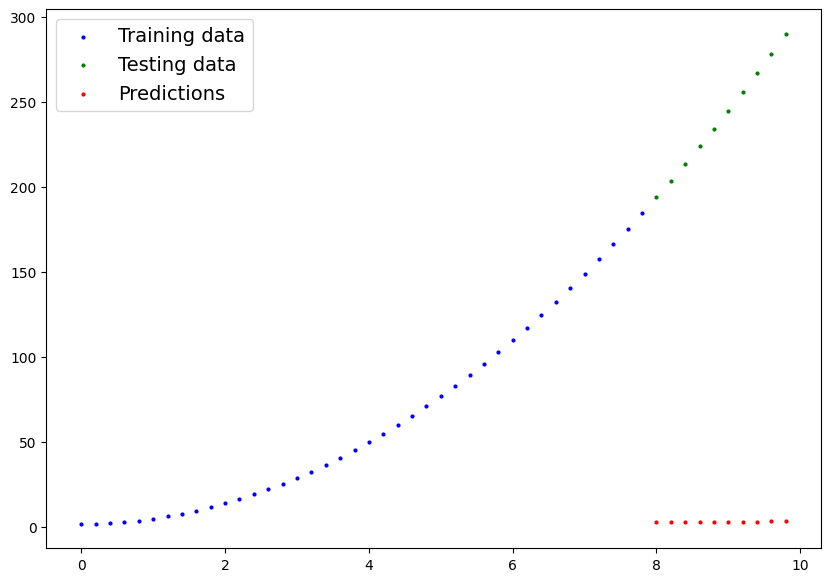

In [13]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

A loss function measures the error between the predicted values and the actual target values. It helps the model understand how well it is performing and guides the optimization process during training. The choice of loss function depends on the type of machine learning problem.

For regression tasks, the most commonly used loss function is Mean Squared Error (MSE) because it penalizes larger errors more heavily and helps the model achieve accurate predictions.
MAE is the average absolute difference between true values (y_i) and predictions (ŷ_i).

i.e. MSE Formula: $$\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert$$

Where:

yi= actual value

y^i= predicted value

n = number of samples

-Lower MAE → better fit.

-More robust to outliers than MSE (no squaring).


### Mpdel Training Process:

The training process involves:

-Forward pass (prediction)
-Loss calculation
-Backpropagation (loss.backward())
-Parameter update (optimizer.step())

This cycle is repeated for multiple epochs until the model learns the underlying pattern in the data.

### Model Prediction:

After training, the model can predict outputs for unseen input data. The learned parameters are used to estimate continuous target values accurately.

### Model Evaluation:

Model performance is evaluated by examining the loss value and comparing predicted outputs with actual values. A lower error indicates that the regression model has successfully captured the relationship between the variable


In [15]:
# Loss Function Selection
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [16]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 62.17809295654297 | MAE Test Loss: 237.13754272460938 
Epoch: 10 | MAE Train Loss: 60.557098388671875 | MAE Test Loss: 233.56655883789062 
Epoch: 20 | MAE Train Loss: 58.93609619140625 | MAE Test Loss: 229.9955596923828 
Epoch: 30 | MAE Train Loss: 57.315101623535156 | MAE Test Loss: 226.424560546875 
Epoch: 40 | MAE Train Loss: 55.694091796875 | MAE Test Loss: 222.853515625 
Epoch: 50 | MAE Train Loss: 54.073097229003906 | MAE Test Loss: 219.2825164794922 
Epoch: 60 | MAE Train Loss: 52.45208740234375 | MAE Test Loss: 215.71151733398438 
Epoch: 70 | MAE Train Loss: 50.831092834472656 | MAE Test Loss: 212.14053344726562 
Epoch: 80 | MAE Train Loss: 49.21009063720703 | MAE Test Loss: 208.5695343017578 
Epoch: 90 | MAE Train Loss: 47.637943267822266 | MAE Test Loss: 205.05331420898438 


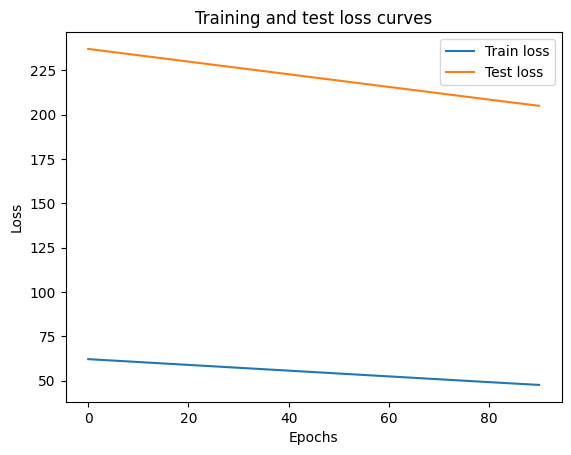

In [17]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [18]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([4.2199]), 'bias': tensor([1.1033])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


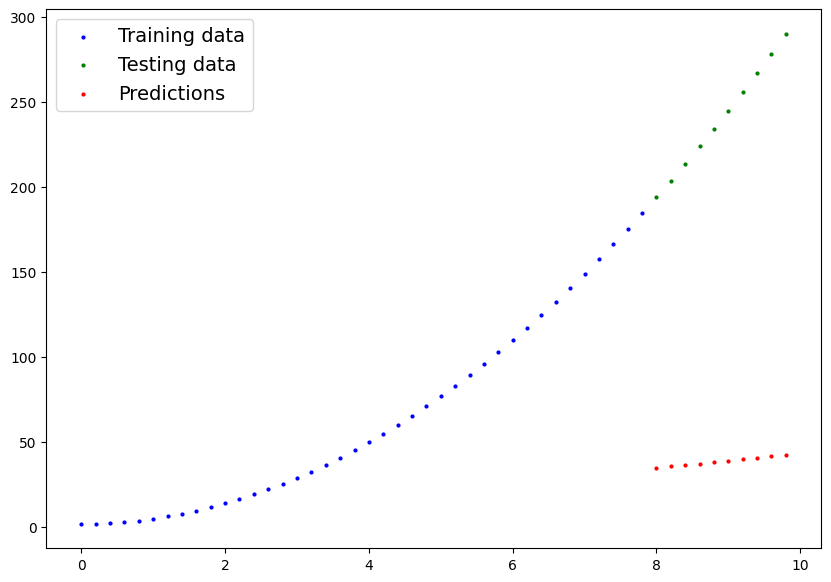

In [20]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

### Discussion and Conclusion:

In this lab, a Linear Regression model was implemented using PyTorch to predict continuous values. The model was trained using tensors, a suitable loss function (MSE), and an optimizer to update parameters through gradient descent. During training, the loss gradually decreased, indicating that the model successfully learned the relationship between the input features and target values.

This lab demonstrated the implementation of regression using PyTorch. The model was able to learn from the training data and make accurate predictions by minimizing the loss function. The experiment provided practical knowledge of tensors, model training, loss functions, and optimization techniques, highlighting the effectiveness of PyTorch for machine learning tasks.